# Experiment 1 (mixture), three ways

A **1-D nonconvex prior** where everything is available in closed form, and the
inversion is **exact** (monotone bisection to machine precision). That is the
point of this run: with the optimizer removed from the comparison, any gap
between the two LPN routes is the recovery *mathematics*, not a solver artifact.

| method | what it does | class |
|---|---|---|
| **LPN Iterative recovery** | fit $\psi_\theta$, then invert it per query: $J_1(y)=\langle y,w\rangle-\psi(w)-\tfrac12 y^2$ | 1-semiconvex |
| **One-shot recovery** | fit $G_\theta\approx\psi_\theta^{*}$ on conjugate pairs; $J_2 = G-\tfrac12 y^2$ | 1-semiconvex |
| **Direct fit** | plain ICNN with $\nabla J(y_k)=x_k-y_k$ | **convex** |

Both LPN routes inherit $-\tfrac12\|\cdot\|^2$ from the Fenchel formula, so they
are 1-semiconvex *for free*. The direct fit is convex by construction, which is
an undocumented **assumption** about the prior -- invisible on TV (where it wins)
and fatal here (the exact prior has curvature $\approx -0.91$).

Outputs land in `pnp_reg/results/`; nothing outside that directory is written.


## 1. Configuration

Edit `PRESET` and `SIGMA`. Everything else is derived.

In [36]:
PRESET = "full"      # "smoke" (~1 min)  |  "full" (~30-60 min on CPU)
SIGMA  = 0.5          # noise level of the mixture denoiser

SMOKE = (PRESET == "smoke")
if SMOKE:
    print("NOTE: smoke is a PLUMBING CHECK -- 500 steps. The numbers it prints are")
    print("      not meaningful; use PRESET = 'full' before reading any result.")
    print("")
print(f"preset {PRESET}, sigma {SIGMA}")


preset full, sigma 0.5


In [37]:
import os, sys, importlib, time

# Notebooks have no __file__, so anchor the paths by walking up for the repo
# root -- the directory that contains BOTH src/ and pnp_reg/.
ROOT = os.path.abspath(os.getcwd())
while not (os.path.isdir(os.path.join(ROOT, "src"))
           and os.path.isdir(os.path.join(ROOT, "pnp_reg"))):
    parent = os.path.dirname(ROOT)
    assert parent != ROOT, "repo root not found -- open this notebook inside the repo"
    ROOT = parent

# src.* needs the root; pnpreg.* needs pnp_reg/ itself.
for p in (ROOT, os.path.join(ROOT, "pnp_reg")):
    if p not in sys.path:
        sys.path.insert(0, p)

RESULTS = os.path.join(ROOT, "pnp_reg", "results")
print("repo root :", ROOT)
print("results   :", RESULTS)
print("python    :", sys.executable)


repo root : /Users/oluwatosin/Downloads/lpn_for_nonconvex_control
results   : /Users/oluwatosin/Downloads/lpn_for_nonconvex_control/pnp_reg/results
python    : /opt/anaconda3/envs/lpn_env_image/bin/python


## 2. Import the experiment

In process, so the kernel's interpreter is the one that runs it.

In [38]:
from pnpreg import threeway_mixture as tm
importlib.reload(tm)          # picks up edits to threeway_mixture.py

print("network / training config:")
for k, v in tm.CFG.items():
    print(f"  {k:8s} {v}")
print(f"\nsteps this run: {500 if SMOKE else tm.CFG['steps']}")


network / training config:
  hidden   64
  layers   2
  beta     20
  batch    512
  steps    20000
  seed     1

steps this run: 20000


## 3. Overrides (optional)

Change the network or the budget here rather than editing the `.py`. Anything you
set on `tm.CFG` is picked up by the next `tm.run(...)` call.


In [39]:
tm.CFG["hidden"] = 128      # width of the ICNN
tm.CFG["layers"] = 2
tm.CFG["beta"]   = 20       # Softplus sharpness
tm.CFG["batch"]  = 512
tm.CFG["seed"]   = 1        # <- change this to measure run-to-run spread
tm.CFG["steps"]  = 40_000   # only used when PRESET == "full"

print({k: tm.CFG[k] for k in ("hidden", "layers", "beta", "batch", "steps", "seed")})


{'hidden': 128, 'layers': 2, 'beta': 20, 'batch': 512, 'steps': 40000, 'seed': 1}


## 4. Train and score all three methods

In [40]:
t0 = time.time()
out = tm.run(sigma=SIGMA, smoke=SMOKE)
print(f"\ntotal {(time.time() - t0) / 60:.1f} min")


sigma=0.5  t=0.25  n=20000  steps=40000

exact min curvature on the window: -0.9113   (floor -1/t = -4.0, f_reg units -1)
window [-2.212, 2.211]

method                     class             rel-L2   min curv     resid   train s    eval s
--------------------------------------------------------------------------------------------
LPN Iterative recovery     1-semiconvex       0.03%    -0.9120     0.17%      96.0     2.024
One-shot recovery          1-semiconvex       0.17%    -0.9619     0.08%     191.6     0.016
Direct fit                 convex           101.21%    -0.0048    59.37%      96.4     0.015
--------------------------------------------------------------------------------------------
exact                      1-semiconvex          --    -0.9113
-> /Users/oluwatosin/Downloads/lpn_for_nonconvex_control/pnp_reg/results/figs/threeway_mixture_sigma0.5.png / .pdf

-> /Users/oluwatosin/Downloads/lpn_for_nonconvex_control/pnp_reg/results/threeway_mixture_sigma0.5.json

total 4.8 mi

## 5. Results table

In [41]:
JSON_PATH = os.path.join(RESULTS, f"threeway_mixture_sigma{SIGMA}.json")
EXACT_KEY = "exact_min_curv"
COLS = ["rel-L2", "min curvature", "prox residual", "train s", "eval s"]
FMT = {
    "rel-L2":        lambda r: f"{100 * r['rel_l2']:.2f}%",
    "min curvature": lambda r: f"{r['min_curv']:+.4f}",
    "prox residual": lambda r: f"{100 * r['resid_median']:.2f}%",
    "train s":       lambda r: f"{r['train_s']:.1f}",
    "eval s":        lambda r: f"{r['eval_s']:.3f}",
}
import json
from IPython.display import Markdown, display

with open(JSON_PATH) as fh:
    out = json.load(fh)

hdr = ["method", "class"] + [c for c in COLS]
lines = ["| " + " | ".join(hdr) + " |",
         "|" + "|".join(["---"] * len(hdr)) + "|"]
for r in out["rows"]:
    cells = [r["method"], r["cls"]] + [FMT[c](r) for c in COLS]
    lines.append("| " + " | ".join(cells) + " |")
display(Markdown("\n".join(lines)))
print(f"exact min curvature: {out[EXACT_KEY]:+.4f}   (semiconvexity floor -1)")


| method | class | rel-L2 | min curvature | prox residual | train s | eval s |
|---|---|---|---|---|---|---|
| LPN Iterative recovery | 1-semiconvex | 0.03% | -0.9120 | 0.17% | 96.0 | 2.024 |
| One-shot recovery | 1-semiconvex | 0.17% | -0.9619 | 0.08% | 191.6 | 0.016 |
| Direct fit | convex | 101.21% | -0.0048 | 59.37% | 96.4 | 0.015 |

exact min curvature: -0.9113   (semiconvexity floor -1)


**How to read it.** `min curvature` is the whole experiment. The exact prior dips
to about $-0.91$; both LPN routes follow it down; the direct fit is pinned at
$\approx 0$ because a convex function *cannot bend downward*. No budget, seed or
width changes that -- it is a statement about the function class, not the fit.


## 6. Figure

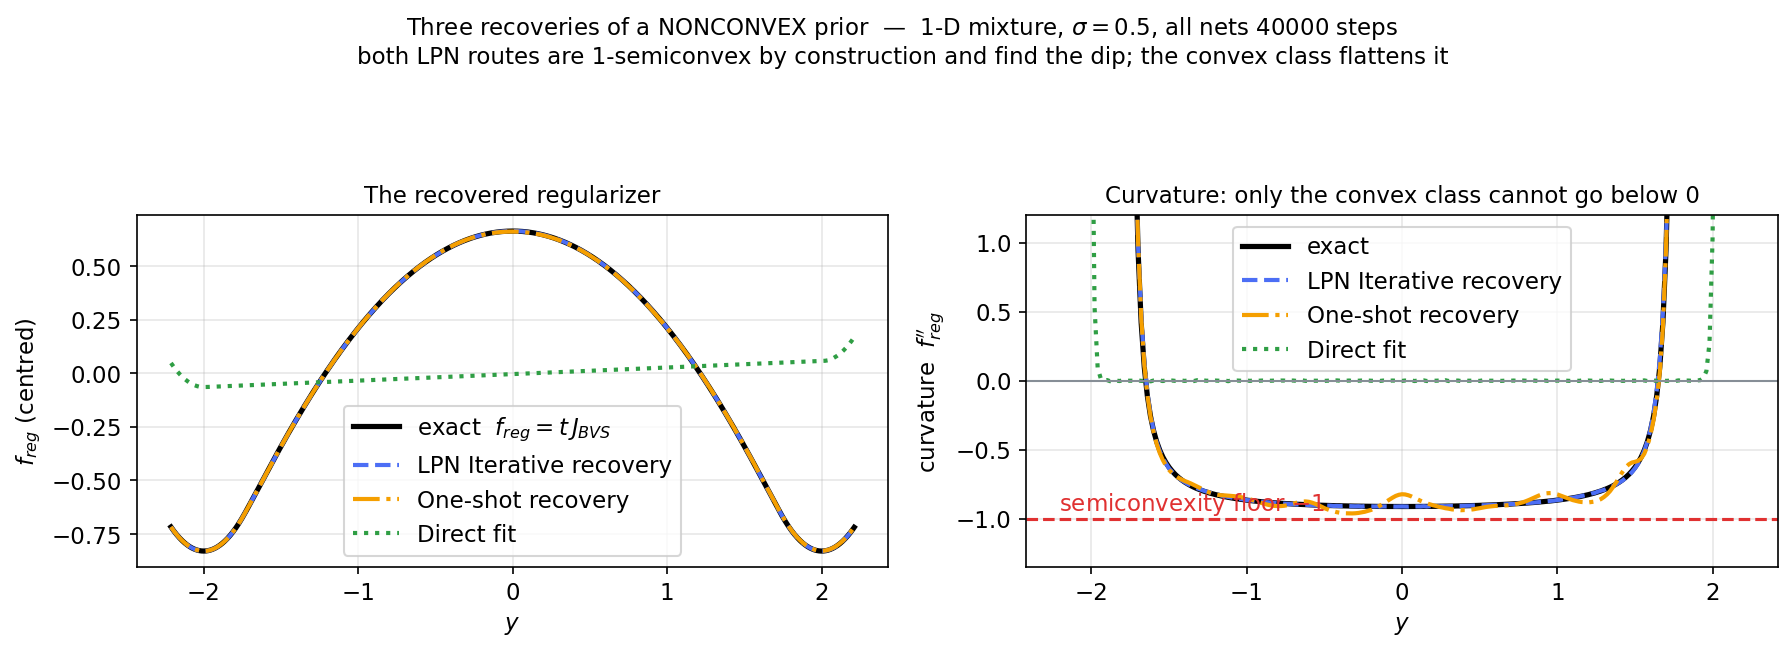

In [42]:
FIG_PATH = os.path.join(RESULTS, "figs", f"threeway_mixture_sigma{SIGMA}.png")
from IPython.display import Image, display
import os
if os.path.exists(FIG_PATH):
    display(Image(filename=FIG_PATH))
else:
    print("figure not found:", FIG_PATH)


## 7. Editing the experiment

The logic lives in `pnp_reg/pnpreg/threeway_mixture.py`. After editing it, re-run
cell 2 (`importlib.reload(tm)`) -- no kernel restart needed.

Useful entry points in that file:

| function | what it does |
|---|---|
| `invert_psi` | the exact bisection inversion (`iters`, `lo`, `hi`) |
| `J_iterative` | the Fenchel read-off $\langle y,w\rangle-\psi(w)-\tfrac12 y^2$ |
| `curvature` | second difference on the decimated stencil |
| `run` | data -> three fits -> metrics -> figure |

**Artifacts written** (all under `pnp_reg/results/`):

```
threeway_mixture_sigma<SIGMA>.json
threeway_mixture_curves_s<SIGMA>.npz
figs/threeway_mixture_sigma<SIGMA>.png / .pdf
ckpt/threeway_mixture_{psi,G,direct}_s<SIGMA>.pth
```

Note the JSON uses the `sigma<S>` spelling while the checkpoints use `s<S>`.
